In [41]:
#IMPORTER LES PACKAGES
import matplotlib.pyplot as plt 
import pandas as pd
import tensorflow as tr
import numpy as np
# import chain
from itertools import chain
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt

In [42]:
df = pd.read_excel('/content/SWGDN.xlsx')
df.head()

,Id,Station,Lon,Lat,Type Data,Année,M,J,DATA
0,1,ES SENIA,-0.625,35.75,SWGDN,1980,1,1,2317.2617
1,2,ES SENIA,-0.625,35.75,SWGDN,1980,1,2,3020.3125
2,3,ES SENIA,-0.625,35.75,SWGDN,1980,1,3,2364.9102
3,4,ES SENIA,-0.625,35.75,SWGDN,1980,1,4,3254.7656
4,5,ES SENIA,-0.625,35.75,SWGDN,1980,1,5,2227.3867


In [43]:
#NORMALISATION DES DONNÉES
scaler = MinMaxScaler(feature_range=(0,1)) #normaliser les données entre 0 et 1
df[['DATA']] = scaler.fit_transform(df[['DATA']])
df.head()

,Id,Station,Lon,Lat,Type Data,Année,M,J,DATA
0,1,ES SENIA,-0.625,35.75,SWGDN,1980,1,1,0.221210
1,2,ES SENIA,-0.625,35.75,SWGDN,1980,1,2,0.303536
2,3,ES SENIA,-0.625,35.75,SWGDN,1980,1,3,0.226790
3,4,ES SENIA,-0.625,35.75,SWGDN,1980,1,4,0.330989
4,5,ES SENIA,-0.625,35.75,SWGDN,1980,1,5,0.210686


In [44]:
#preparer les données d'apprentissage de teste et de validation
train = df.loc[(df['Année']  <= 2017) & (df['Année']  >= 2010)][['DATA']] #80%
validation = df.loc[df['Année'] == 2018][['DATA']] #10%
test = df.loc[df['Année'] == 2019][['DATA']] #10%
print(type(train))
train.head()

<class 'pandas.core.frame.DataFrame'>


,DATA
10913,0.209371
10914,0.300758
10915,0.293691
10916,0.314153
10917,0.119849


In [45]:
#transformer dataframe en liste
train = train.values
test = test.values
validation = validation.values
train 
print(type(train))
print(train)

<class 'numpy.ndarray'>
[[0.20937094]
 [0.3007577 ]
 [0.29369118]
 ...
 [0.2984272 ]
 [0.32329109]
 [0.20735869]]


In [46]:
#Preparation des données d'entré et de sortie
x_test = []
y_test = []
x_train = [] #[[1,2,3,4,5,6],[2,3,4,5,6,7],[...8],[....9]]
y_train = [] #[7,8,9,10]
x_validation = []
y_validation = []
look_back = 6

for i in range(len(train)-6):
  x_train.append(train[i:(i+look_back),0])
  y_train.append(train[i+look_back,0])
x_train,y_train = np.array(x_train), np.array(y_train)

for i in range(len(test)-6):
  x_test.append(test[i:(i+look_back),0])
  y_test.append(test[i+look_back,0])
x_test,y_test = np.array(x_test), np.array(y_test)

for i in range(len(test)-6):
  x_validation.append(validation[i:(i+look_back),0])
  y_validation.append(validation[i+look_back,0])
x_validation,y_validation = np.array(x_validation), np.array(y_validation)

print(type(x_test))
print(x_test[len(test)-7])
print(y_test[len(test)-8])

<class 'numpy.ndarray'>
[0.10094863 0.19933708 0.2384525  0.17194416 0.31138288 0.27074474]
0.2707447365381523


In [47]:
best_rmse = float('inf')
best_mae = float('inf')
best_mlp_RMSE = MLPRegressor() 
best_mlp_MAE = MLPRegressor() 
best_j_rmse = 0 # meilleur nombre de neurone pour chaque couche pour le RMSE
best_i_rmse = 0 #meilleur nombre de couche pour le RMSE
best_j_mae = 0 # meilleur nombre de neurone pour chaque couche pour le mae
best_i_mae = 0 #meilleur nombre de couche pour le mae
i_list = []
j_list = []
rmse_list = [] #liste des rmse normalisé
mae_list = [] #liste des mae normalisé
rmse_list_dd = [] #liste des rmse non normalisé
mae_list_dd = [] #liste des mae non normalisé
  
for i in range(1,4):
    for j in range(1,101):
        arch_size = (j,) * i
        mlp= MLPRegressor(hidden_layer_sizes=arch_size, activation='logistic',learning_rate_init = 0.01, momentum=0.7, max_iter=1000)
        mlp.fit(x_train,y_train)
        val_pred=mlp.predict(x_validation)
        rmse= mean_squared_error(y_validation, val_pred,squared= False) # squared a False pour calculer le rmse
        mae = mean_absolute_error(y_validation, val_pred)
        i_list.append(i)
        j_list.append(j)
        rmse_list.append(rmse)
        mae_list.append(mae)
        y_validation_dd = list(chain.from_iterable(scaler.inverse_transform([y_validation])))
        y_pred_dd = list(chain.from_iterable(scaler.inverse_transform([val_pred])))
        rmse_d= mean_squared_error(y_validation_dd, y_pred_dd,squared= False) # squared a False pour calculer le rmse
        rmse_list_dd.append(rmse_d)
        if rmse < best_rmse:
            best_rmse = rmse
            best_mlp_RMSE = mlp
            best_i_rmse=i
            best_j_rmse=j
        if mae < best_mae:
            best_mae = mae
            best_mlp_MAE = mlp
            best_i_mae=i
            best_j_mae=j
        

In [48]:
print("Meilleur Erreur RMSE est:",best_rmse ,"de parametre ",best_i_rmse,"couche cachee et ",best_j_rmse," reseaux de neurons ") 
print("Meilleur Erreur MAE est:",best_mae ,"de parametre ",best_i_mae,"couche cachee et ",best_j_mae," reseaux de neurons ") 

i_list_temp = i_list.copy()
j_list_temp = j_list.copy()

Meilleur Erreur RMSE est: 0.1208952116816003 de parametre  3 couche cachee et  6  reseaux de neurons 
Meilleur Erreur MAE est: 0.08668466930086856 de parametre  3 couche cachee et  39  reseaux de neurons 


In [49]:
#dans cette partie on recupere les 10 meilleur rmse pour chaque  couche (1,2,3)

couche1_rmse = rmse_list_dd[:100]
couche2_rmse = rmse_list_dd[100:200]
couche3_rmse = rmse_list_dd[200:300]
i_list_temp_1 = i_list_temp[:100]
i_list_temp_2 = i_list_temp[100:200]
i_list_temp_3 = i_list_temp[200:300]
j_list_temp_1 = j_list_temp[:100]
j_list_temp_2 = j_list_temp[100:200]
j_list_temp_3 = j_list_temp[200:300]
#recuperer les indices des 10 meilleurs rmse pour chaque couche
idx_1 = np.argsort(couche1_rmse)[:10]
idx_2 = np.argsort(couche2_rmse)[:10]
idx_3 = np.argsort(couche3_rmse)[:10]

print(i_list_temp_1)
#idx_graph = [*idx_1, *idx_2, *idx_3]

rmse_graph1 = [ couche1_rmse[i] for i in idx_1]
rmse_graph2 = [ couche2_rmse[i] for i in idx_2]
rmse_graph3 = [ couche3_rmse[i] for i in idx_3]

i_list_graph1 = [ i_list_temp_1[i] for i in idx_1]
i_list_graph2 = [ i_list_temp_2[i] for i in idx_2]
i_list_graph3 = [ i_list_temp_3[i] for i in idx_3]

j_list_graph1 = [ j_list_temp_1[i] for i in idx_1]
j_list_graph2 = [ j_list_temp_2[i] for i in idx_2]
j_list_graph3 = [ j_list_temp_3[i] for i in idx_3]

print(rmse_graph2)
print(i_list_graph2)
print(j_list_graph2)

rmse_graph = [*rmse_graph1, *rmse_graph2, *rmse_graph3]
i_list_graph = [*i_list_graph1, *i_list_graph2, *i_list_graph3]
j_list_graph = [*j_list_graph1, *j_list_graph2, *j_list_graph3]

print(rmse_graph)
print(i_list_graph)
print(j_list_graph)


[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1034.5832267080584, 1036.4327289962362, 1036.7811389494095, 1038.1786697293403, 1038.3204285524853, 1039.1204536828145, 1039.443100644012, 1039.9787105956314, 1040.3979182050002, 1040.498487561763]
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
[7, 2, 10, 4, 3, 1, 9, 8, 92, 81]
[1037.9884736924864, 1039.849686601469, 1039.9466911405218, 1040.0577891456614, 1040.1634318083488, 1040.9721678710164, 1041.0923864989923, 1041.197908157199, 1041.3093092932918, 1041.4602973382882, 1034.5832267080584, 1036.4327289962362, 1036.7811389494095, 1038.1786697293403, 1038.3204285524853, 1039.1204536828145, 1039.443100644012, 1039.9787105956314, 1040.3979182050002, 1040.498487561763, 1032.4366281707191, 1032.956303762322,

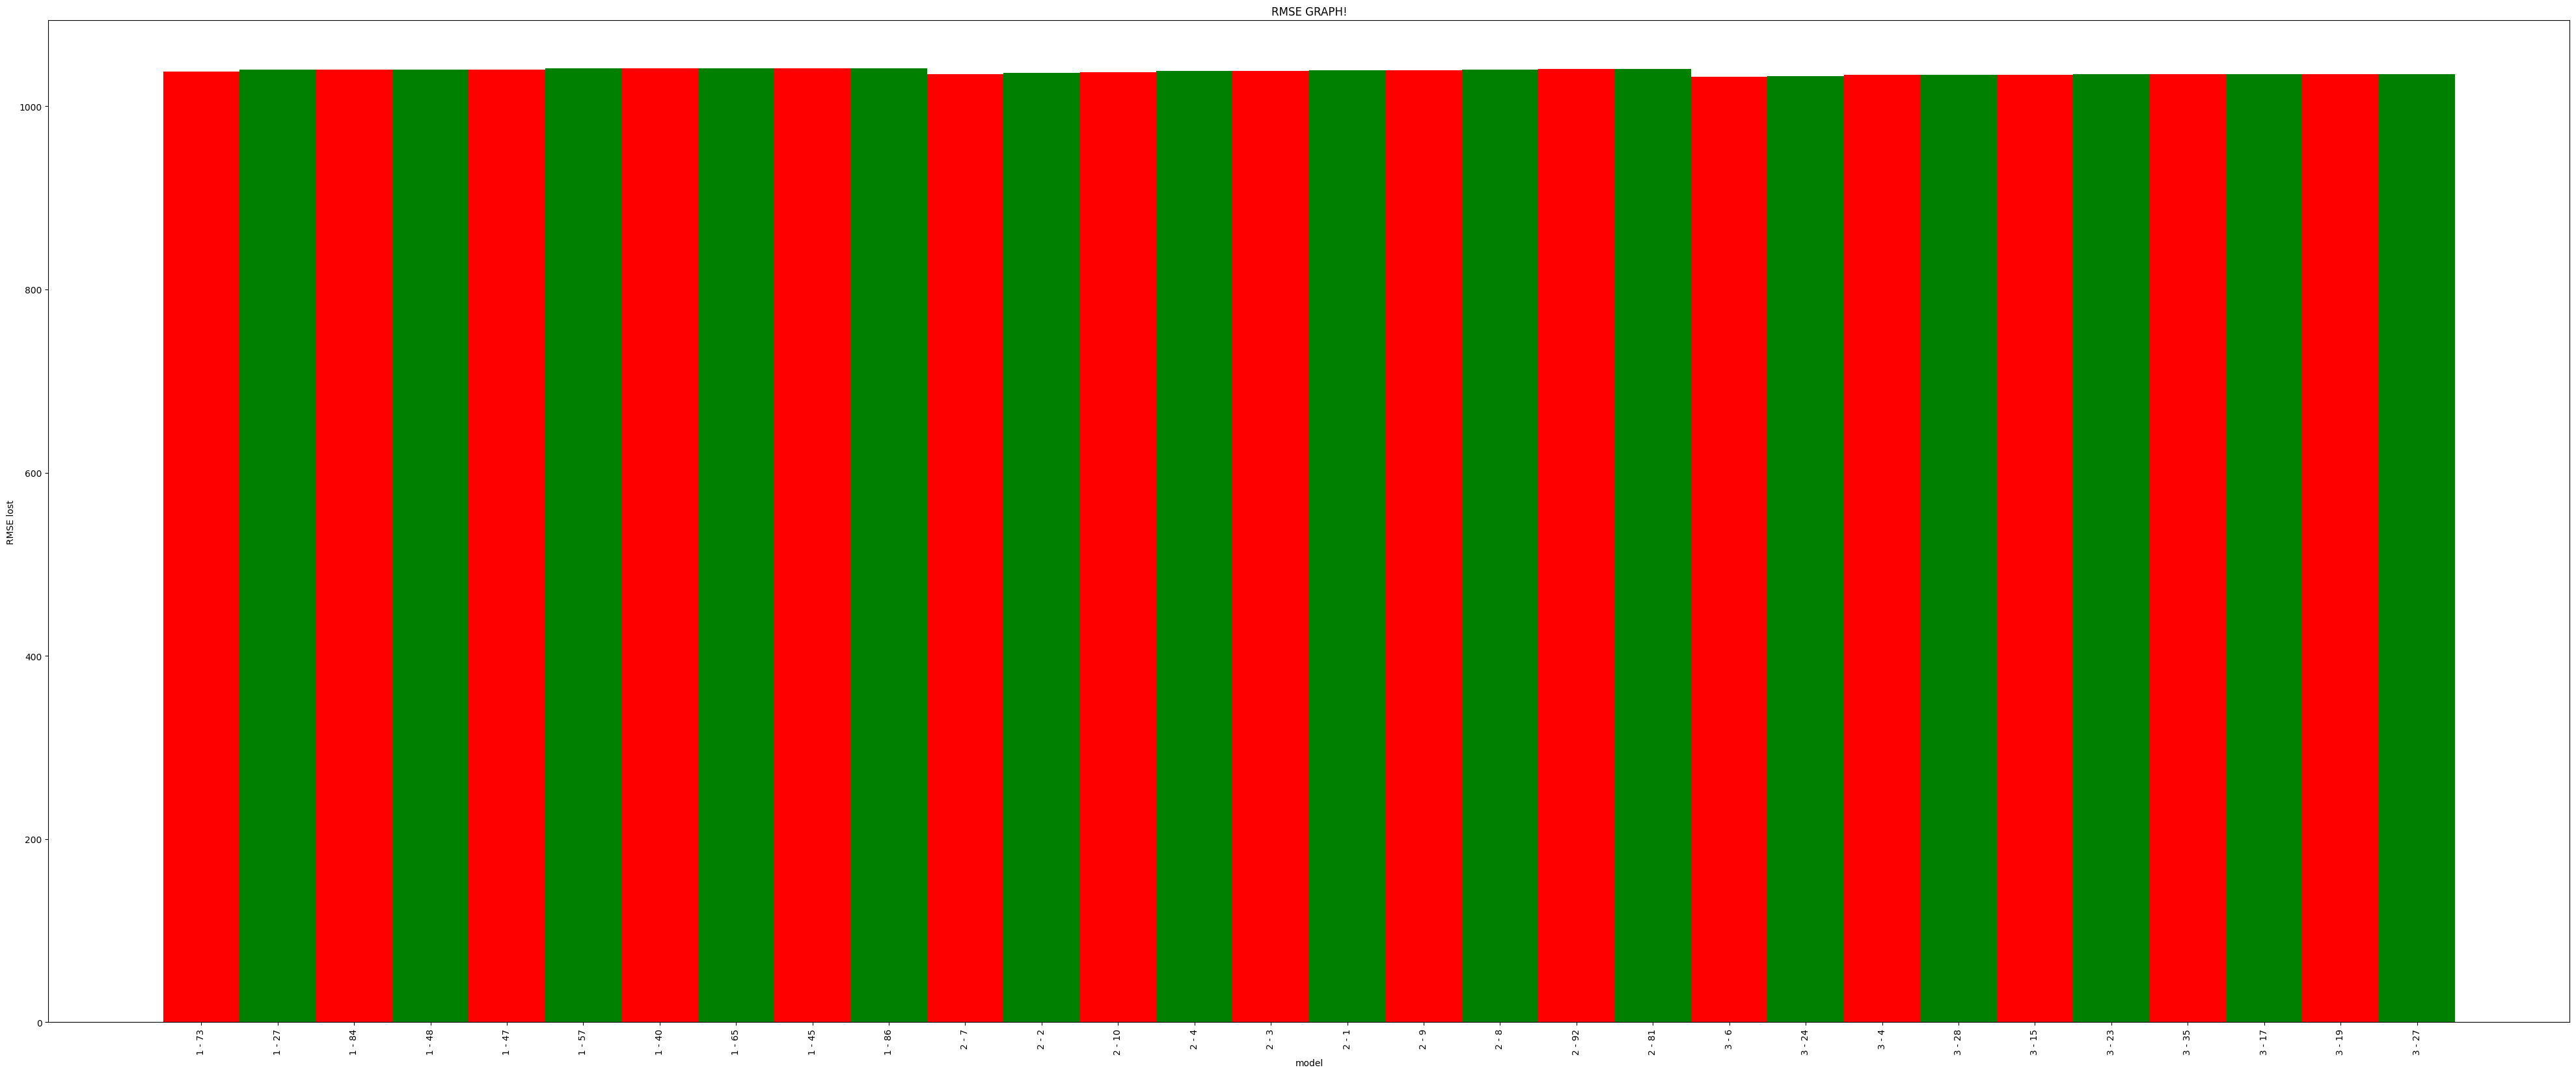

In [50]:
## Les RMSE en fonction des couches cachées 10 min pour chaque couche
i_list_graph_c = i_list_graph.copy()
plt.rcParams["figure.figsize"] = (50,20) # taille de graph
left = list(np.arange(0,(len(i_list_graph)),1))
# plotting a bar chart
for i in range(len(i_list_graph)):
  i_list_graph_c[i] = str(i_list_graph[i]) + ' - ' + str(j_list_graph[i])
plt.bar(left, rmse_graph, tick_label = i_list_graph_c,
        width = 1, color = ['red', 'green'])
# x-axis
plt.xlabel('model')
plt.xticks(rotation=90)
# y-axis
plt.ylabel('RMSE lost')

# plot title
plt.title('RMSE GRAPH!')

plt.show()


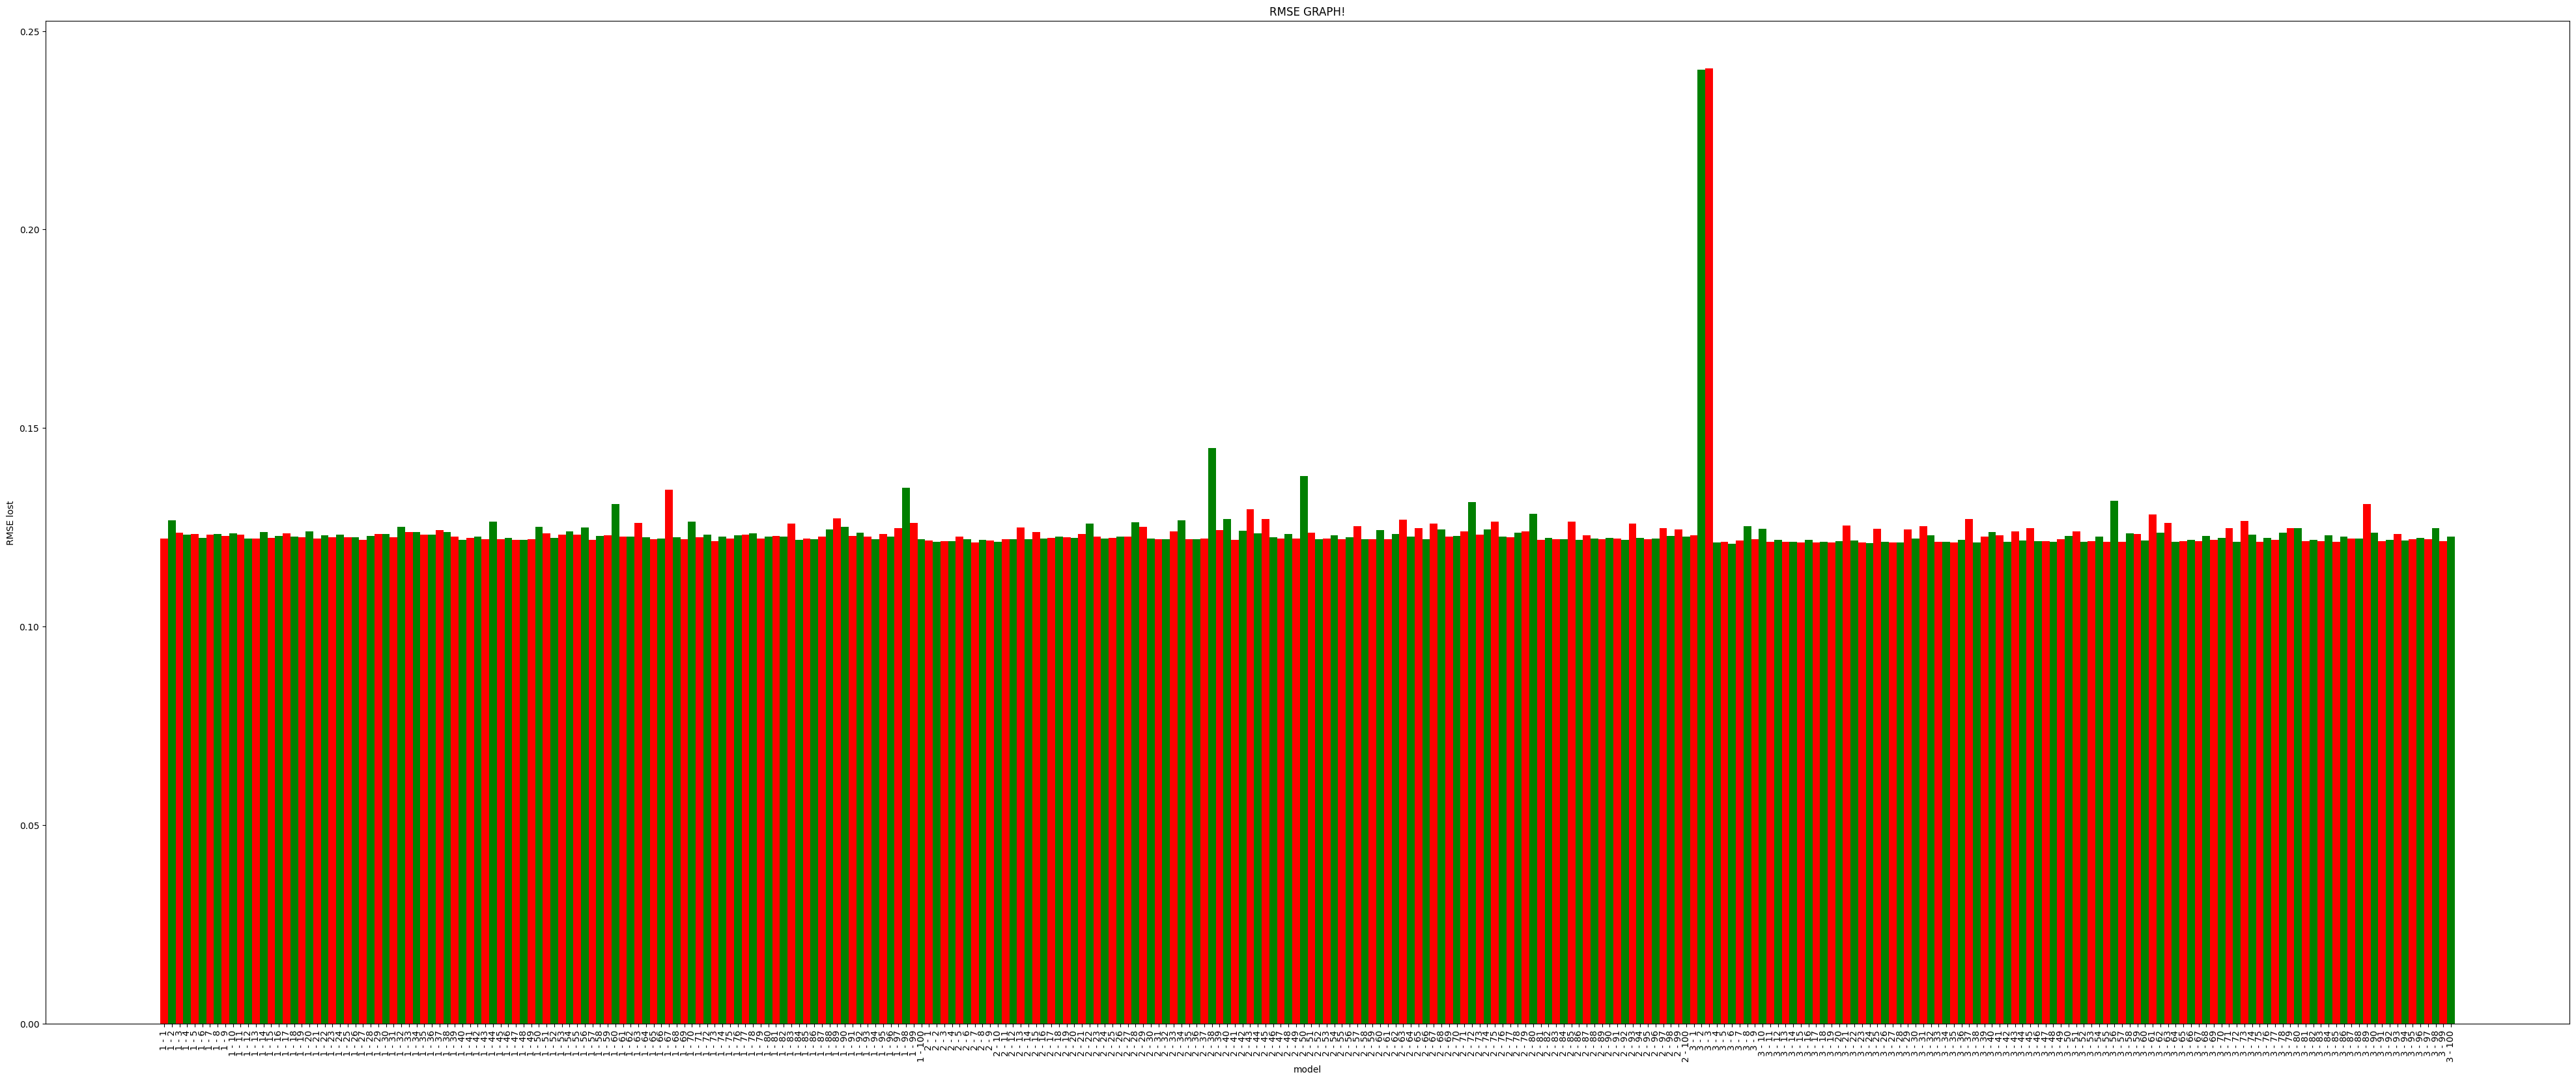

In [51]:
import matplotlib.pyplot as plt
import openpyxl

# Les RMSE en fonction des couches cachées
plt.rcParams["figure.figsize"] = (50,20) # taille de graph
left = list(np.arange(0,(len(i_list)),1))
# plotting a bar chart
for i in range(len(i_list)):
  i_list_temp[i] = str(i_list_temp[i]) + ' - ' + str(j_list_temp[i])
plt.bar(left, rmse_list, tick_label = i_list_temp,
        width = 1, color = ['red', 'green'])
#x-axis
plt.xlabel('model')
plt.xticks(rotation=90)
#y-axis
plt.ylabel('RMSE lost')

# plot title
plt.title('RMSE GRAPH!')

plt.show()

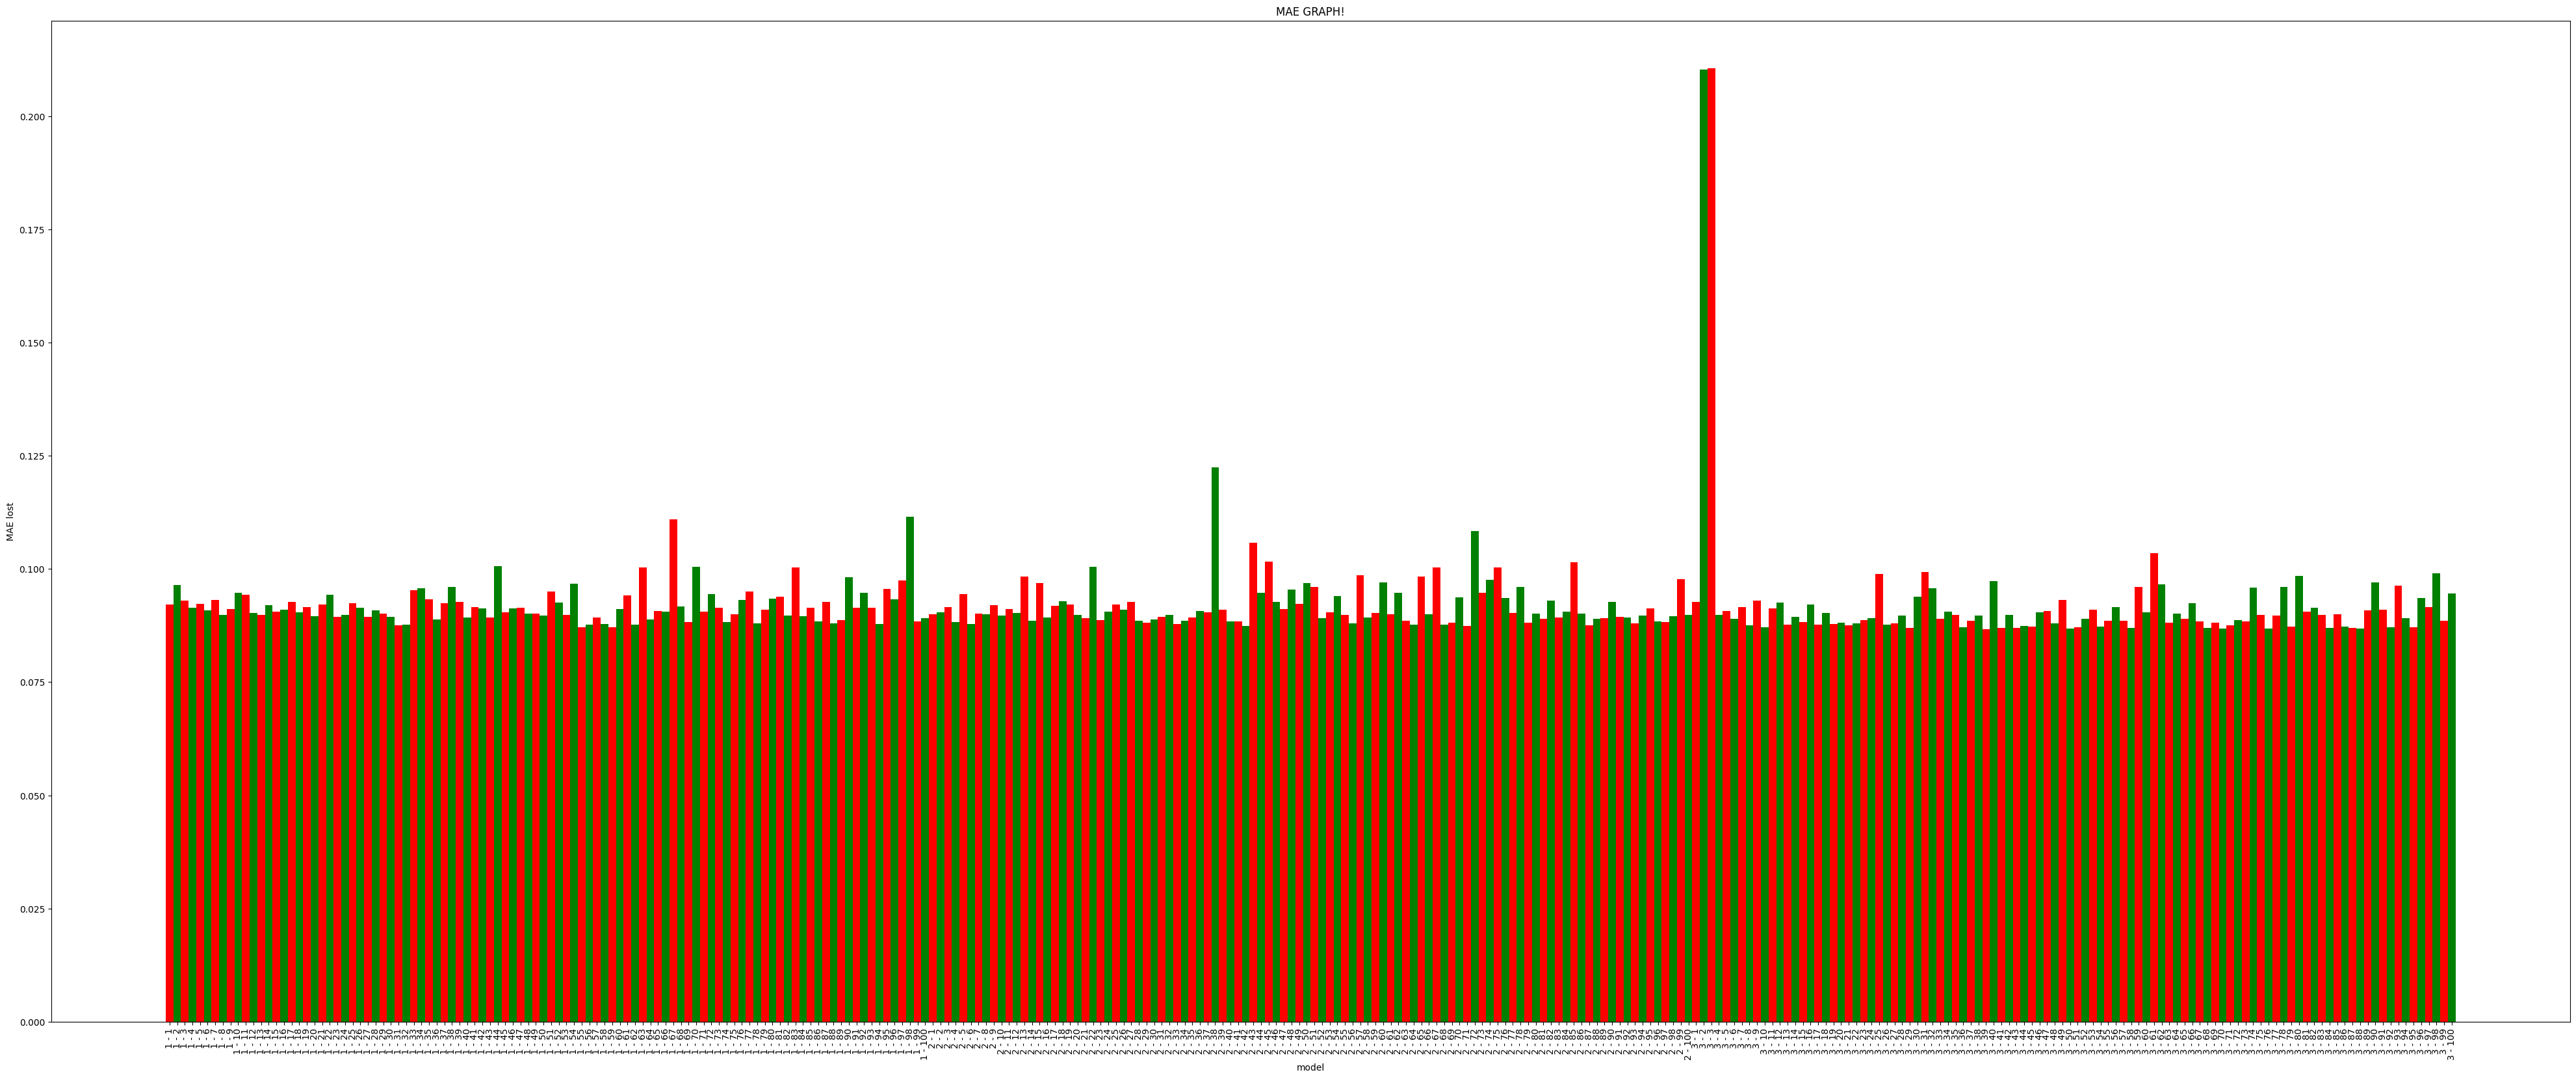

In [52]:
# Les MAE en fonction des couches cachées
plt.rcParams["figure.figsize"] = (50,20) # taille de graph

plt.bar(left, mae_list, tick_label = i_list_temp,
        width = 1, color = ['red', 'green'])
# naming the x-axis
plt.xlabel('model')
plt.xticks(rotation=90)
# naming the y-axis
plt.ylabel('MAE lost')

# plot title
plt.title('MAE GRAPH!')
  
# function to show the plot
plt.show()

1032.4366281707191


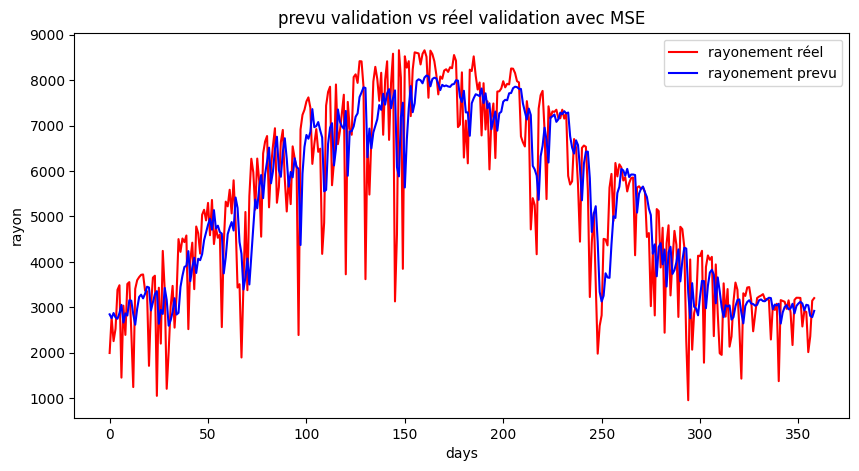

In [53]:
# rayonnement prevu validation vs réel validation avec MSE
y_pred=best_mlp_RMSE.predict(x_validation)


#denormaliser les données
y_validation_d = list(chain.from_iterable(scaler.inverse_transform([y_validation])))
y_pred_d = list(chain.from_iterable(scaler.inverse_transform([y_pred])))

rmse_d= mean_squared_error(y_validation_d, y_pred_d,squared= False) # squared a False pour calculer le rmse
print(rmse_d)

plt.rcParams["figure.figsize"] = (10,5)
plt.plot(y_validation_d,color='red',label='rayonement réel')
plt.plot(y_pred_d,color='blue',label='rayonement prevu')
plt.title('prevu validation vs réel validation avec MSE')
plt.xlabel('days')
plt.ylabel('rayon')
plt.legend()
plt.show()

740.2809957667126


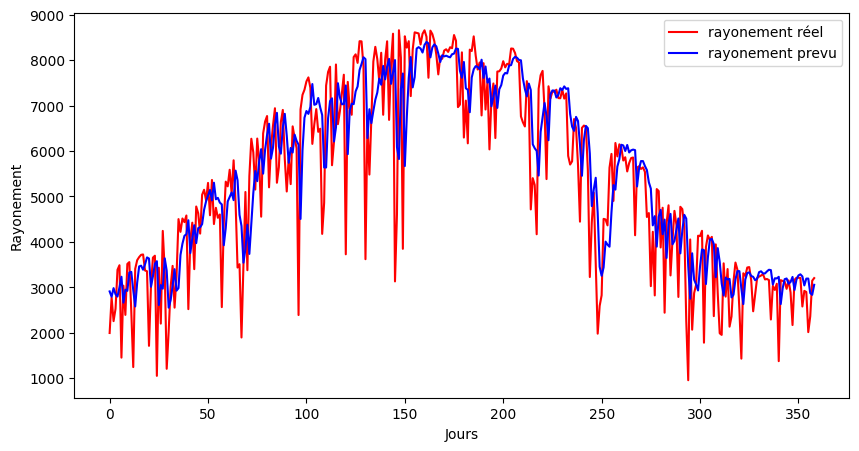

In [54]:
# rayonnement prevu validation vs réel validation avec mae
y_pred=best_mlp_MAE.predict(x_validation)
#Denormaliser les données
y_validation_d = list(chain.from_iterable(scaler.inverse_transform([y_validation])))
y_pred_d = list(chain.from_iterable(scaler.inverse_transform([y_pred])))

mae_d = mean_absolute_error(y_validation_d, y_pred_d)
print(mae_d)


plt.rcParams["figure.figsize"] = (10,5)
plt.plot(y_validation_d,color='red',label='rayonement réel')
plt.plot(y_pred_d,color='blue',label='rayonement prevu')
#plt.title('prevu validation vs réel validation avec MAE')
plt.xlabel('Jours')
plt.ylabel('Rayonement')
plt.legend()
plt.show()

915.1077354922236


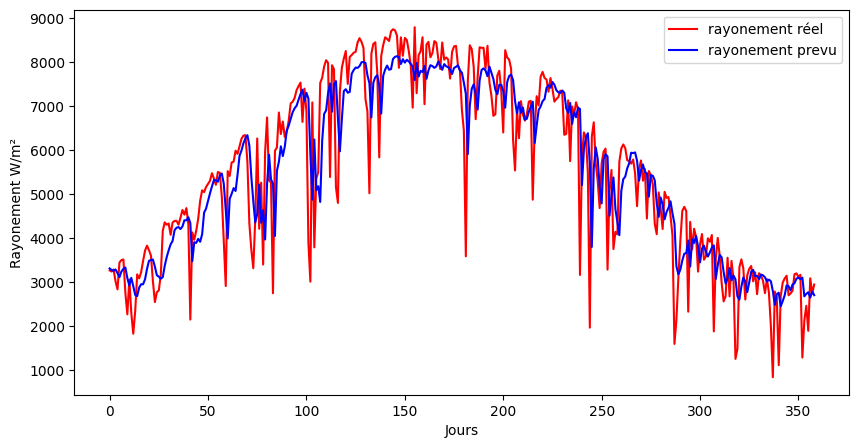

In [55]:
# rayonnement prevu test vs réel test avec RMSE
y_pred = best_mlp_RMSE.predict(x_test)
#denormaliser les données
y_test_d = list(chain.from_iterable(scaler.inverse_transform([y_test])))
y_pred_d = list(chain.from_iterable(scaler.inverse_transform([y_pred])))


rmse_d= mean_squared_error(y_test_d, y_pred_d,squared= False) # squared a False pour calculer le rmse


print(rmse_d)

plt.rcParams["figure.figsize"] = (10,5)
plt.plot(y_test_d,color='red',label='rayonement réel')
plt.plot(y_pred_d,color='blue',label='rayonement prevu')
#plt.title('prevu test vs réel test avec RMSE')
plt.xlabel('Jours')
plt.ylabel('Rayonement W/m²')
plt.legend()
plt.show()

620.473959242269


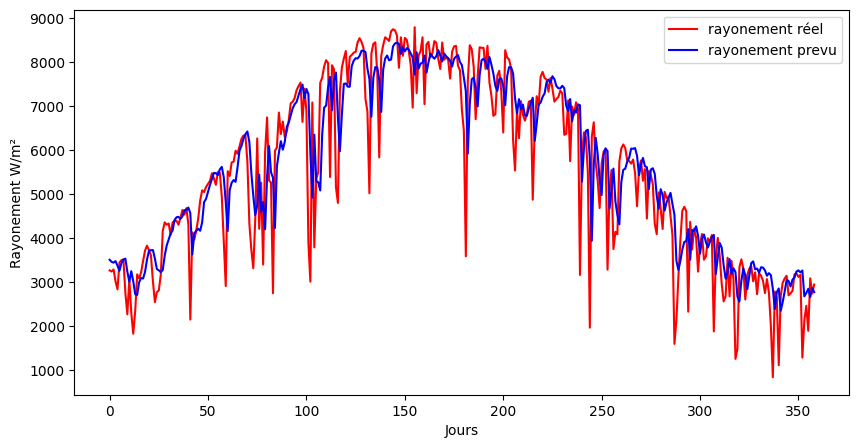

In [56]:
# rayonnement prevu test vs réel test avec RMSE
y_pred = best_mlp_MAE.predict(x_test)
#denormaliser les données
y_test_d = list(chain.from_iterable(scaler.inverse_transform([y_test])))
y_pred_d = list(chain.from_iterable(scaler.inverse_transform([y_pred])))

mae_d = mean_absolute_error(y_test_d, y_pred_d)
print(mae_d)

plt.rcParams["figure.figsize"] = (10,5)
plt.plot(y_test_d,color='red',label='rayonement réel')
plt.plot(y_pred_d,color='blue',label='rayonement prevu')
#plt.title('prevu test vs réel test avec MAE')
plt.xlabel('Jours')
plt.ylabel('Rayonement W/m²')
plt.legend()
plt.show()

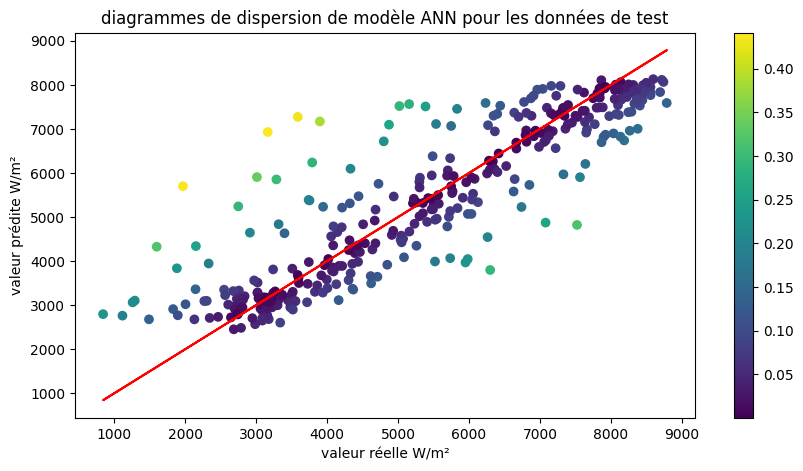

In [57]:
#graph de despersion
# diagrammes de dispersion de modèle ANN pour les données de test

y_pred = best_mlp_RMSE.predict(x_test)
#denormaliser les données


c=[np.abs(y_test[i]-y_pred[i]) for i in range(0,359)]

#test_pred=scaler.inverse_transform(y_pred) #.reshape(358,1)

#y_test=scaler.inverse_transform(y_test)

y_test_d = list(chain.from_iterable(scaler.inverse_transform([y_test])))
y_pred_d = list(chain.from_iterable(scaler.inverse_transform([y_pred])))

plt.figure(figsize=(10,5))

plt.scatter(y_test_d,y_pred_d,c=c)

plt.plot(y_test_d,y_test_d,c='r')

plt.xlabel("valeur réelle W/m²")

plt.ylabel("valeur prédite W/m²")

plt.title("diagrammes de dispersion de modèle ANN pour les données de test")

plt.colorbar()

plt.show()